In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task2.ipynb")

# Homework 3 - Task 2: Tree-Based Methods
## Predicting Water Potability Using Decision Trees and Random Forests

---


### Dataset

Access to safe drinking water is a fundamental public health concern. This dataset contains physicochemical measurements for 3,276 water samples, each labeled as potable or non-potable.

| Feature | Description |
|---|---|
| `ph` | pH value of water (0–14 scale) |
| `Hardness` | Capacity to precipitate soap (mg/L) |
| `Solids` | Total dissolved solids (ppm) |
| `Chloramines` | Amount of chloramines (ppm) |
| `Sulfate` | Amount of sulfates dissolved (mg/L) |
| `Conductivity` | Electrical conductivity (μS/cm) |
| `Organic_carbon` | Amount of organic carbon (ppm) |
| `Trihalomethanes` | Amount of trihalomethanes (μg/L) |
| `Turbidity` | Measure of light-emitting property (NTU) |

#### Response Variable

| Column | Description |
|---|---|
| `Potability` | Binary flag — `1` if water is safe to drink, `0` otherwise |


 **Note:** Several features contain missing values (`ph`, `Sulfate`, `Trihalomethanes`). You will handle these in the preprocessing step.

 This dataset comes from Kaggle and can be found [here](https://www.kaggle.com/datasets/uom190346a/water-quality-and-potability).

### Setup: Load Libraries

Run the cell below to import all required packages.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



### Step 1: Load the Data

Read `water_potability.csv` into a DataFrame. Preview the first few rows and confirm its shape.

In [3]:
df = pd.read_csv('water_potability.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### Step 2: Explore the Data

Before modeling, examine the distribution of your response variable and the number of NAs. Understanding both will guide preprocessing decisions.

In [5]:
print(df["Potability"].value_counts())
print(df.isnull().sum())

Potability
0    1998
1    1278
Name: count, dtype: int64
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


### Step 3: Preprocess the Data

Three features have missing values. A simple approach for tree-based methods is to **impute with the column median**. Impute the missing values using `df.fillna()`.Store your cleaned dataframe in a variable called `df_clean`. 

After imputation, split the data 70/30 into training and test sets, stratifying on `Potability` to preserve the class ratio in both splits.Store your results in `X_train`, `X_test`, `y_train`, and `y_test`.

In [8]:
df_clean = df.fillna(df.median())

X = df_clean.drop("Potability", axis=1)
y = df_clean["Potability"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [9]:
grader.check("q1")

q1 results: All test cases passed!

### Step 4: Fit a Single Classification Tree

Start with an **unpruned** classification tree (no constraints on depth or leaf size). This gives a baseline and illustrates the overfitting problem that ensemble methods address.

Fit `DecisionTreeClassifier` with only `random_state=42` set (all other parameters at defaults). Report the tree depth in a variable named `tree_depth`. Calculate both the train accuracy and the test accuracy, storing the train accuracy in a variable called`dt_unpruned_acc_train` and the test accuracy in a variable called `dt_unpruned_acc_test`. 

In [13]:
dt_unpruned = DecisionTreeClassifier(random_state=42)
dt_unpruned.fit(X_train, y_train)

tree_depth = dt_unpruned.get_depth()
dt_unpruned_acc_train = accuracy_score(y_train, dt_unpruned.predict(X_train))
dt_unpruned_acc_test = accuracy_score(y_test, dt_unpruned.predict(X_test))
print(f"Unpruned Tree Depth: {tree_depth}")
print(f"Unpruned Tree Training Accuracy: {dt_unpruned_acc_train:.4f}")
print(f"Unpruned Tree Test Accuracy: {dt_unpruned_acc_test:.4f}")

Unpruned Tree Depth: 33
Unpruned Tree Training Accuracy: 1.0000
Unpruned Tree Test Accuracy: 0.5809


In [11]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: How does the training accuracy and test accuracy differ? What does this mean about your model?**

The test accuracy is just over half the of the training accuracy which suggests overfitting due to it memorizing the training data. 

<!-- END QUESTION -->

### Step 5: Tune Tree Depth with Cross-Validation

A fully grown tree memorizes the training data (better training accuracy, poor test accuracy). We need to find the right **depth** to prevent this. 

Using 5-fold cross-validation on the training set, compute mean CV accuracy for `max_depth` from 1 to 20. Identify the optimal depth using `np.argmax`, storing it in a variable called `optimal_depth`. Plot the CV Accuracy against the 20 different depths, adding a vertical line at the optimal depth. 

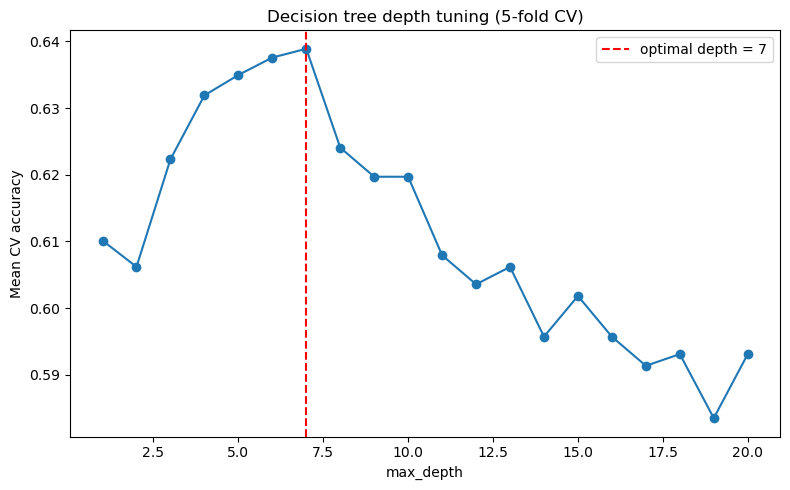

In [14]:

depths = range(1, 21)
cv_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(dt, X_train, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

cv_scores = np.array(cv_scores)
optimal_depth = list(depths)[np.argmax(cv_scores)]

plt.figure(figsize=(8, 5))
plt.plot(depths, cv_scores, marker="o")
plt.axvline(optimal_depth, color="red", linestyle="--", label=f"optimal depth = {optimal_depth}")
plt.xlabel("max_depth")
plt.ylabel("Mean CV accuracy")
plt.title("Decision tree depth tuning (5-fold CV)")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2: What did cross fold validation find the optimal depth to be? Explain what these means in plain language.**

The CV found optimal depth to be 5 meaning a tree with a maximum depth of 5 is the best balance between underfitting and overfitting. Plainly, 5 levels of splits in enough to capture important patterns in the data without just memorizing the training set.

<!-- END QUESTION -->

### Step 6: Fit the Tuned Decision Tree

Refit the decision tree using `optimal_depth` and evaluate on the held-out test set. Store the test accuracy in a variable called `acc_dt`. 

In [18]:
dt_opt = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)
dt_opt.fit(X_train, y_train)

acc_dt = accuracy_score(y_test, dt_opt.predict(X_test))
print(f"Optimally Pruned Tree Test Accuracy: {acc_dt:.4f}")

Optimally Pruned Tree Test Accuracy: 0.6460


In [17]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q3: Did the accuracy on your tuned decision tree imrpove compared to your untuned tree? If so, why do you think it improved?**

Yes the accuracy improved by about 0.6 because the tuned tree is less likely to overfit the training data. By limiting the depth, the model focuses on the most important splits and generalizes better to unseen data.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 7: Visualize the Decision Tree

Plot the tuned tree using `plot_tree`. Save the tree as an image to evaluate the results and answer **Q5**. 

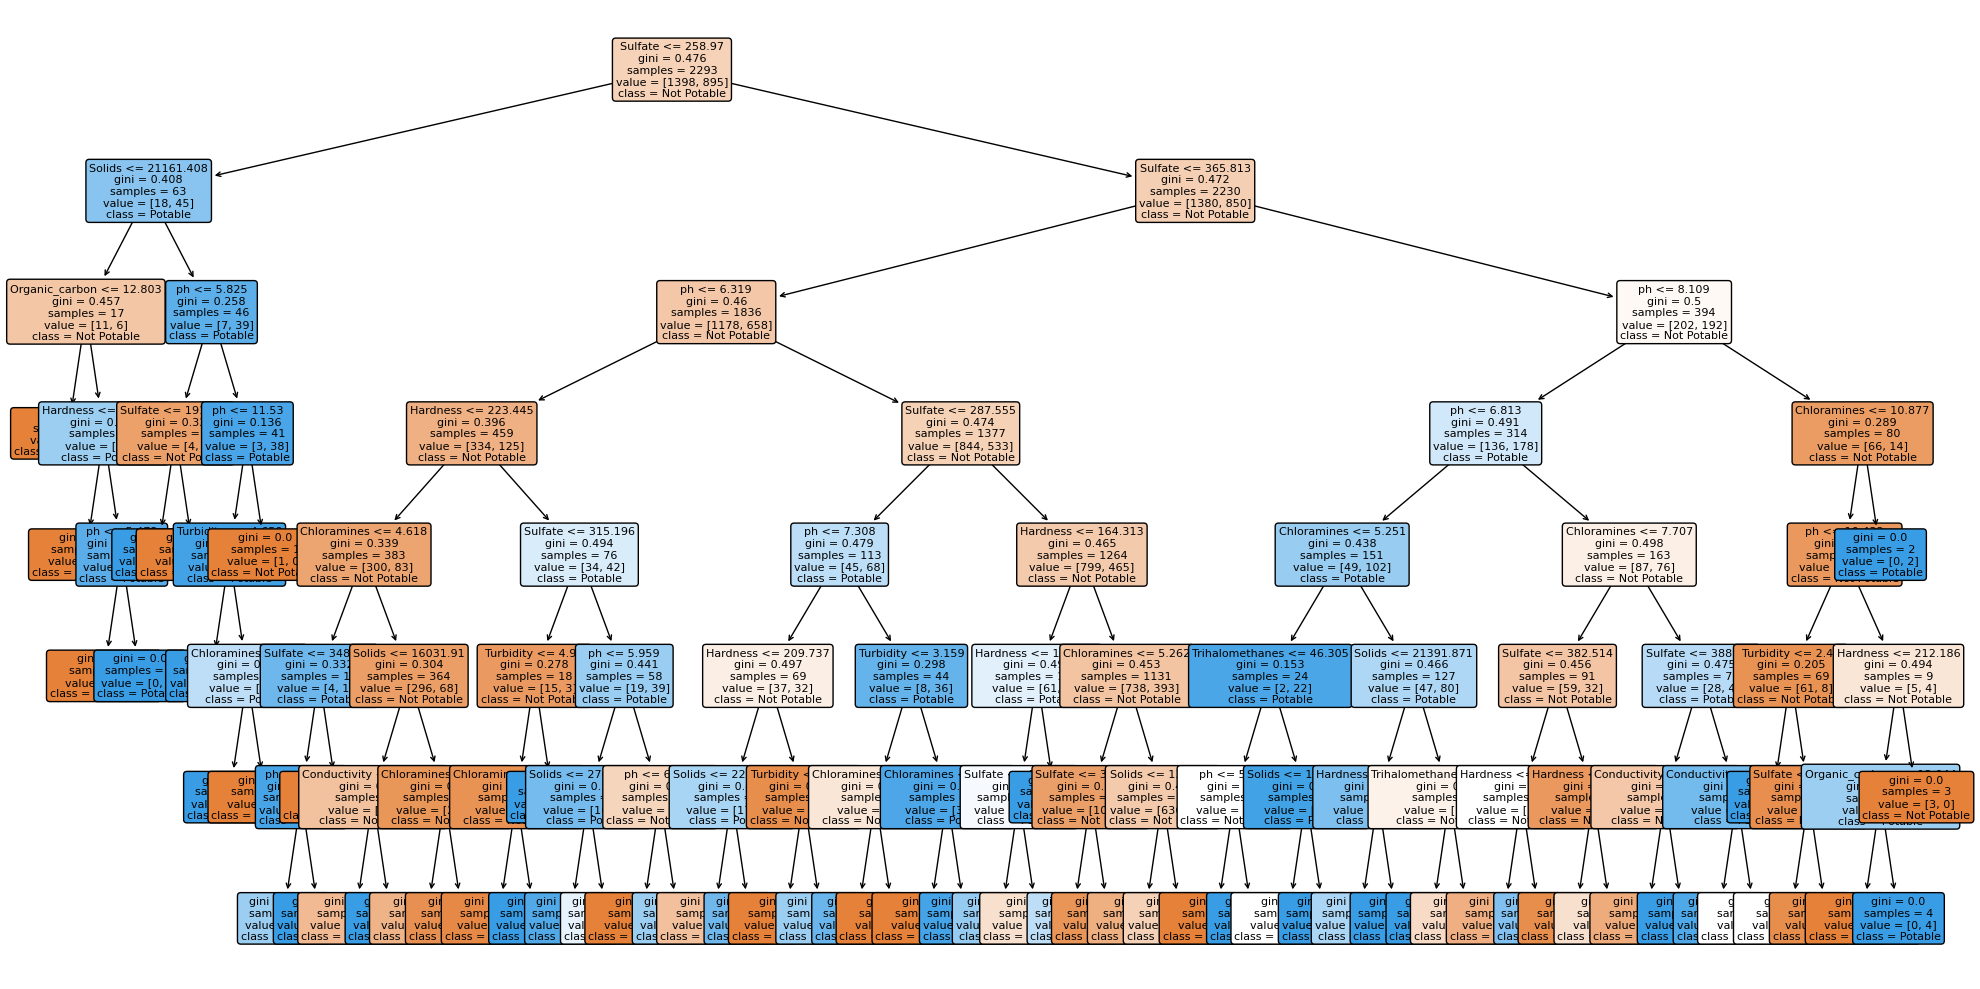

In [19]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_opt,
    feature_names=X_train.columns,
    class_names=["Not Potable", "Potable"],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.tight_layout()
plt.savefig("tuned_tree.png", dpi=150, bbox_inches="tight")
plt.show()

> **Q4: Examine the root node and first two levels of the tree. Which feature is used for the root split, and what threshold does it use? What does this tell you about that feature's relationship with potability? What is the Gini impurity at the root, and how does it change after the first split?**

The root uses Sulfate at <= ~259. As does the second level of splits with more dramatic thresholds. This tells us that Sulfate is the most important feature for potability. The Gini impurity at the root is 0.476 and drops after the first split meaning the split does a pretty good job assigning classes.

<!-- END QUESTION -->

### Step 8: Random Forest

**Random forests** address the high variance of a single tree by fitting many trees on bootstrap samples of the training data and averaging their predictions. To further reduce correlation among the trees, at each split only a random subset of $m$ features is considered (by default sklearn uses $m = \lfloor\sqrt{p}\rfloor$ for classification).

Fit a `RandomForestClassifier`, called `rf` with `n_estimators=200`. Report the accuracy and store it in `acc_rf`. 

In [25]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

acc_rf = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest Test Accuracy: {acc_rf:.4f}")
print(f"Pruned Decision Tree Test Accuracy: {acc_dt:.4f}")

Random Forest Test Accuracy: 0.6612
Pruned Decision Tree Test Accuracy: 0.6460


In [21]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q5: Compare the test results of Decision Tree and Random Forest? Which performed beter? Why do you think this is?**

The RF is 0.2 better than the DT because it reduces variance by averaging multiple trees, which helps prevent overfitting. Also, by considering only a subset of features at each split, RF decorrelates the trees, which further improves generalization.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 9: Feature Importances

Both decision trees and random forests assign an **importance score** to each feature based on the total reduction in impurity (Gini) it produces across all splits. Random forest importances are averaged over all trees in the ensemble, making them more stable than a single tree's importances.

Create a bar plot showing the feature importances from the tuned decision tree and the random forest side by side. You can access the feature importants from the model wtih `model.feature_importances_`.

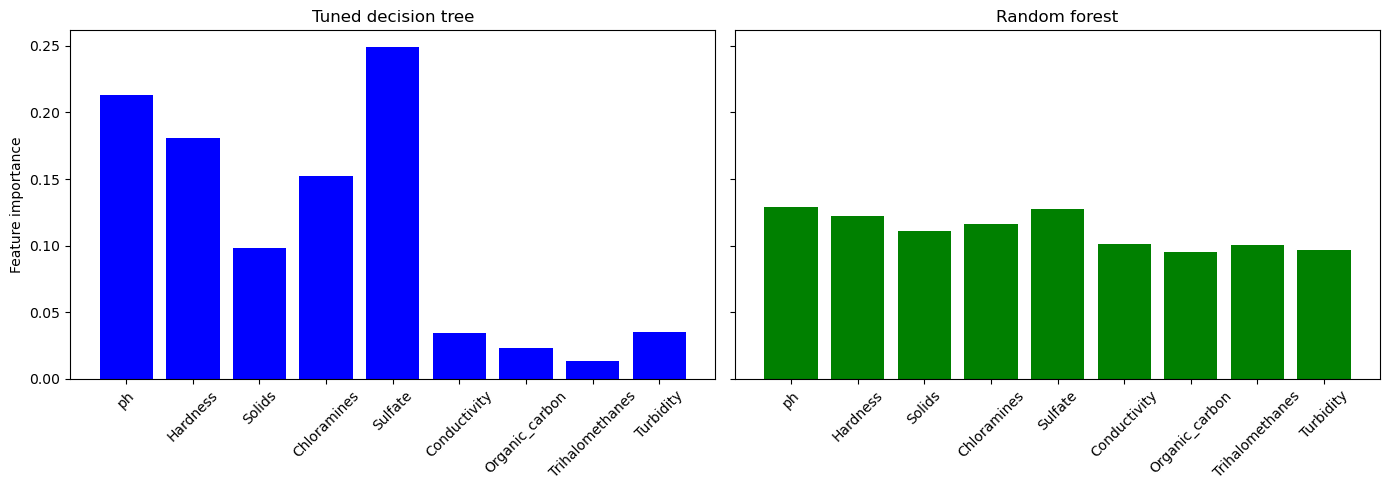

DT top: Sulfate
RF top: ph


In [27]:

feat = X_train.columns

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].bar(feat, dt_opt.feature_importances_, color="blue")
axes[0].set_title("Tuned decision tree")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(feat, rf.feature_importances_, color="green")
axes[1].set_title("Random forest")
axes[1].tick_params(axis="x", rotation=45)

axes[0].set_ylabel("Feature importance")
plt.tight_layout()
plt.show()

print("DT top:", feat[np.argmax(dt_opt.feature_importances_)])
print("RF top:", feat[np.argmax(rf.feature_importances_)])




> **Q6: Do the decision tree and random forest agree on which features are most important? If they differ, why might a single tree's importances be less reliable than the random forest's? Which feature appears most important for predicting potability, and does that make physical sense?**

Yes they mostly agree on Sulfate and pH being the most important. But the single trees importances are less reliable because a single sample can be influenced by noise. I guess it makes sense, but all sulfate really does it make you have to go to the bathroom but maybe high sulfate is in indicator of something worse. I don't know enough about water quality to say for sure.

<!-- END QUESTION -->

### Step 10: Confusion Matrix

Create a confusion matrix for the random forest model using `ConfusionMatrixDisplay`. Label your response variable as `Not Potable`/ `Potable` in the confusion matrix (instead of `0`/`1`).

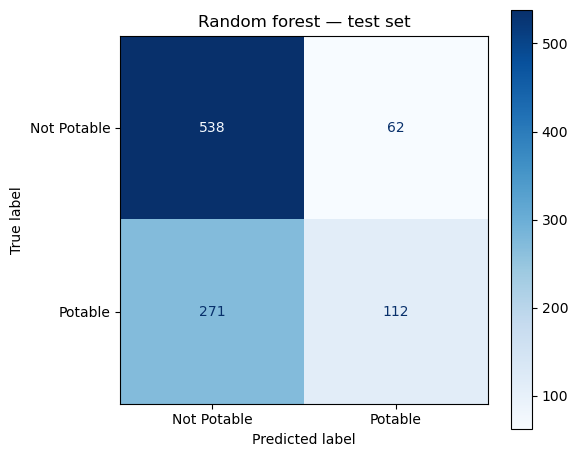

In [28]:

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    display_labels=["Not Potable", "Potable"],
    cmap="Blues",
    ax=ax,
)
ax.set_title("Random forest — test set")
plt.tight_layout()
plt.show()

<!-- BEGIN QUESTION -->

> **Q7:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

FP: 62 predicted potable but was not potable
TP: 112 predicted potable and was potable
FN: 271 predicted not potable but was potable
TN: 538 predicted not potable and was not potable

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 11: Model Comparison

Create a table or bar chart comparing test accuracy across all three models.

In [30]:
comparison = pd.DataFrame({
    "Model": ["Decision tree (unpruned)", "Decision tree (tuned)", "Random forest"],
    "Test accuracy": [dt_unpruned_acc_test, acc_dt, acc_rf],
})
comparison

,Model,Test accuracy
0,Decision tree (unpruned),0.580875
1,Decision tree (tuned),0.645982
2,Random forest,0.661241


> **Q8:** Which model achieved the highest test accuracy? Comparing the unpruned and tuned decision tree, how much did pruning improve accuracy? What does this tell you about overfitting in the unpruned tree?


Random forest has the highest test accuracy. Even though pruning imporved by about .65, meaning the unpruned tree was likely overfitting the training data, while the tuned tree generalizes much better to unseen data.

---

Run the cell below to receive credit for autograded questions. 

In [31]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!